<a href="https://colab.research.google.com/github/gabs-tr-data-analyst/ecommerce-customer-behavior-correlation/blob/main/analisis_novaretail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explorando factores de comportamiento en NovaRetail+



NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**


## Sección 1 - Exploración del dataset

In [8]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/content/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [9]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Explorar Dataset

#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [10]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
  
La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `satisfaccion` se podría convertir a entero para facilitar los cálculos y sobre todo la visualización.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [11]:
# Corregir el tipo de dato
df['satisfaccion'] = df['satisfaccion'].astype(int)

In [12]:
df['edad'] = df['edad'].astype(int)

In [13]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  int64  
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [14]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.160067,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.753978,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.000000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.000000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.000000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Diagnóstico inicial de variables numéricas**:


- `edad` - Se observa que la mediana y media son prácticamente iguales, por lo que no se encuentra sesgo. Se tiene un público adulto joven/maduro muy bien distribuido entre los 18 y 75 años.
- `nivel_ingreso` - Aunque hay una gran brecha entre el mínimo (8000) y el máximo (74790.84) vemos en la mediana y media que no hay mucha dispersión en los datos.
- `visitas_mes` - El comportamiento es consistente (la mayoría visita unas 10 veces), pero el máximo es 25. Se encuentran "heavy users" de la plataforma, aunque no son la regla.
- `compras_mes` - El percentil 25% es 0. Esto significa que al menos una cuarta parte de los usuarios registrados no compraron nada en ese periodo. Hay un sesgo positivo ligero aquí.
- `gasto_publicidad_dirigida` - Muestra una variabilidad moderada. Resalta que el mínimo es 0 dando a entender que hay usuarios que llegan de forma orgánica.
- `satisfaccion` - Dado que la media es 3.16 y la mediana 3.0, se deduce que el cliente promedio está "neutral" o"ligeramente satisfecho". Mejorar ese 3.0 podría ser clave para el equipo de Retención.
- `miembro_premium` - Gracias a la media (0.139) observamos que el 13.9% de la base de clientes son miembros premium.
- `abandono` - Se observa que el 15% de los usuarios han abandonado (churn rate).
- `ingreso_anual` - El 75% de los usuarios genera 58.22 o menos, pero el valor máximo es 244.69. Esos son los clientes VIP. La media (36.5) es notablemente mayor que la mediana (30.7). Esto indica que hay un grupo pequeño de usuarios gastando mucho más que el resto, llevando el promedio hacia arriba.

#### Explorar variables binarias

In [15]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']

for col in columnas_binarias:
    print(f"Frecuencia de valores en '{col}'")
    print(df[col].value_counts(dropna=False))
    print("\n")

Frecuencia de valores en 'miembro_premium'
miembro_premium
0    12911
1     2089
Name: count, dtype: int64


Frecuencia de valores en 'abandono'
abandono
0    12739
1     2261
Name: count, dtype: int64




✍️ **Diagnóstico inicial de variables binarias**:


En términos generales podemos ver que solo existen los valores 0 y 1 en ambas columnas y comprobamos que no hay nulos.
- `miembro_premium` — La gran mayoría de los clientes (más del 86%) no son premium. Esto representa un área de oportunidad grande para el equipo de Growth.
- `abandono` — Una significativa mayoría (85%) no abandona. Vale la pena analizar el 15% que sí lo hace (2,261 usuarios) como el grupo de estudio principal para el equipo de Retención.

#### Explorar variables categóricas

In [16]:
# Verificar el número de valores únicos por variable categórica
df['tipo_dispositivo'].value_counts()

,count
tipo_dispositivo,
móvil,9818
escritorio,3720
tablet,1462


In [17]:
# Explorar variables categóricas y cómo se distribuyen
df['tipo_dispositivo'].value_counts(normalize=True) * 100

,proportion
tipo_dispositivo,
móvil,65.453333
escritorio,24.800000
tablet,9.746667


In [18]:
df['region'].value_counts()

,count
region,
norte,4395
oeste,3810
sur,3726
este,3069


In [19]:
# Explorar variables categóricas y cómo se distribuyen
df['region'].value_counts(normalize=True) * 100

,proportion
region,
norte,29.30
oeste,25.40
sur,24.84
este,20.46


✍️ **Diagnóstico inicial de variables categóricas**:


- `tipo_dispositivo` - Podemos observar que predomina el móvil con un 65.4%, muy por encima del escritorio (24.8%) y tablet (9.7%). Un punto a considerar, ver si hay una relación entre el tipo de dispositivo y el abandono a la plataforma
- `region` - En región lleva la delantera el norte, con 29%, pero no hay una brecha tan grande con el segundo lugar que ocupa el oeste (con 25.4%) que casi empata con el sur (24.8%). Sólo si comparamos el norte con el este (en último lugar con 20.4%) se nota una mayor diferencia de casi 9%. A considerar, qué factores demográficos están influyendo en este sesgo

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

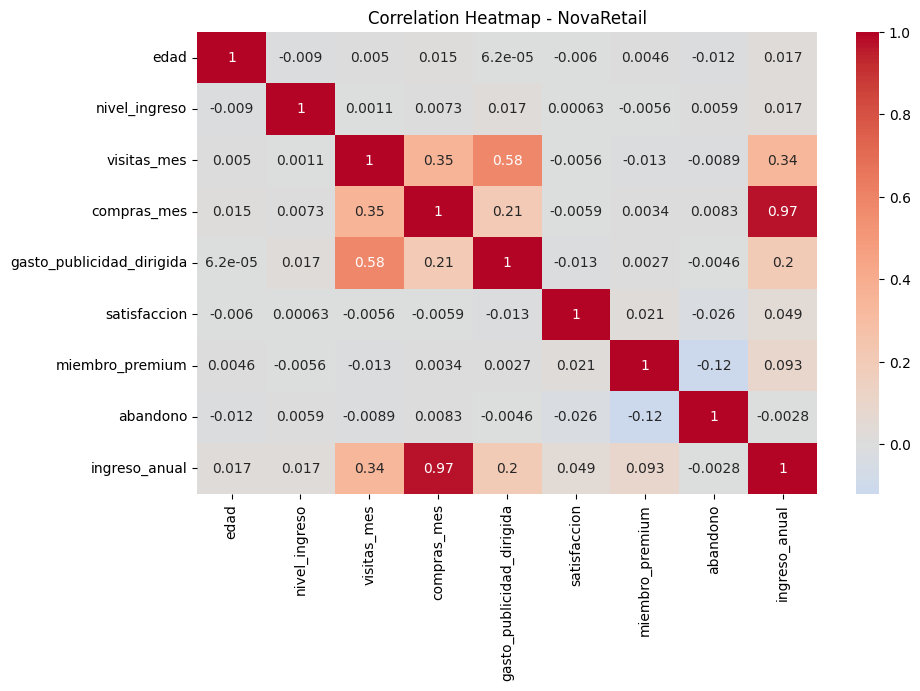

In [20]:
# Visualizar la matriz de correlación para identificar relaciones
# Excluir columnas no numéricas antes de calcular la correlación
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaRetail")
plt.show()

✍️ **Comentario**:

Se observa que la mayoría de las variables analizadas no presentan relación lineal entre sí, reflejado en coeficientes cercanos a cero. No obstante, se identifican las siguientes relaciones relevantes:

El **gasto_publicidad_dirigida** presenta una correlación positiva moderada-fuerte con las visitas_mes (0.58), y éstas, a su vez, correlacionan positivamente con las compras_mes (0.35). Este patrón sugiere que la inversión publicitaria opera como detonador del tráfico, y el tráfico como facilitador de las conversiones.

Variables como **edad y nivel_ingreso** registran coeficientes prácticamente nulos frente a todas las métricas de comportamiento. Esto indica que las acciones de los usuarios dentro de la plataforma no están condicionadas por su perfil sociodemográfico.

**Observaciones respecto a ingreso_anual**

- El ingreso anual presenta un comportamiento altamente concentrado en un conjunto reducido de variables operativas:

- La correlación más elevada de toda la matriz se registra entre compras_mes e ingreso_anual (0.97), haciendo alusión a que el volumen de transacciones es el principal determinante de ingresos.

- El gasto_publicidad_dirigida muestra una correlación directa débil con el ingreso anual (0.20). Su contribución real se materializa de forma indirecta, a través de su influencia sobre el volumen de visitas (0.58).

- Variables que convencionalmente se asocian a la rentabilidad, como satisfaccion (0.049) y miembro_premium (0.093), no presentan correlación lineal significativa con la generación de ingresos anuales.

### Scatterplot general

 - En este caso no se considera relevante un *scatterplot* general, ya que en el heatmap podemos observar que la gran mayoría de las variables no tiene relación entre sí, sin embargo, se considera oportuno explorar los scatterplot de variables concretas, descritas a continuación:

### Scatterplot para pares clave

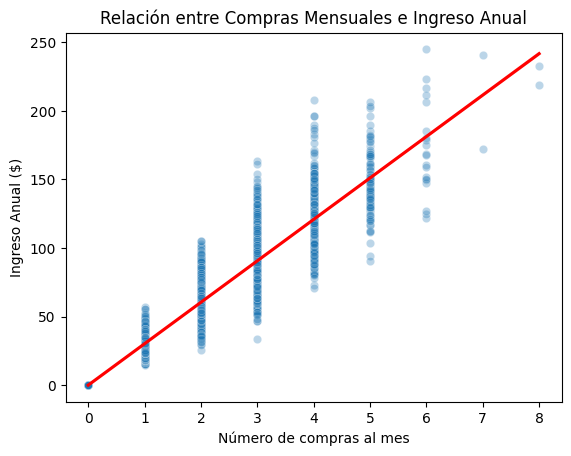

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar pares de variables con relaciones moderadas o fuertes
# Compras vs Ingreso Anual
sns.scatterplot(data=df, x="compras_mes", y="ingreso_anual", alpha=0.3)

sns.regplot(data=df, x="compras_mes", y="ingreso_anual", scatter=False, color='red')

plt.title("Relación entre Compras Mensuales e Ingreso Anual")
plt.xlabel("Número de compras al mes")
plt.ylabel("Ingreso Anual ($)")
plt.show()

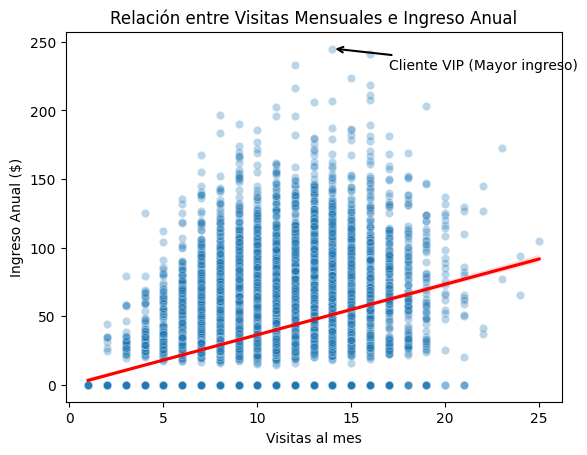

In [22]:

sns.scatterplot(data=df, x="visitas_mes", y="ingreso_anual", alpha=0.3)
sns.regplot(data=df, x="visitas_mes", y="ingreso_anual", scatter=False, color='red')

# Outlier

ax = plt.gca()
ax.annotate(
    "Cliente VIP (Mayor ingreso)",
    xy=(14, 245),
    xytext=(17, 230),
    arrowprops=dict(arrowstyle="->", color='black', lw=1.5)
)

plt.title("Relación entre Visitas Mensuales e Ingreso Anual")
plt.xlabel("Visitas al mes")
plt.ylabel("Ingreso Anual ($)")
plt.show()

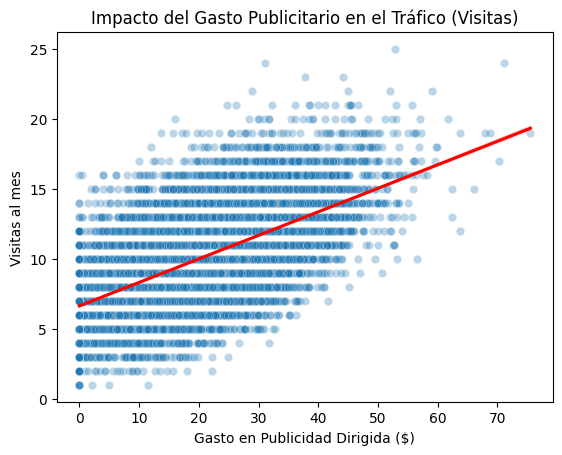

In [23]:
sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes", alpha=0.3)
sns.regplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes", scatter=False, color='red')

plt.title("Impacto del Gasto Publicitario en el Tráfico (Visitas)")
plt.xlabel("Gasto en Publicidad Dirigida ($)")
plt.ylabel("Visitas al mes")
plt.show()

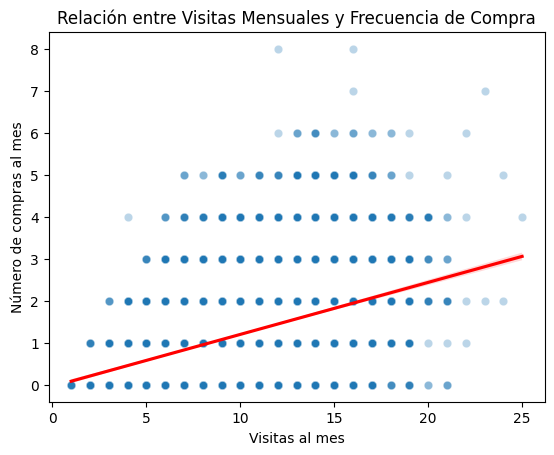

In [24]:
sns.scatterplot(data=df, x="visitas_mes", y="compras_mes", alpha=0.3)
sns.regplot(data=df, x="visitas_mes", y="compras_mes", scatter=False, color='red')

plt.title("Relación entre Visitas Mensuales y Frecuencia de Compra")
plt.xlabel("Visitas al mes")
plt.ylabel("Número de compras al mes")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**Compras mensuales vs Ingreso Anual**

Se observa que la dirección es positiva con una correlación lineal fuerte, comprobando lo visto en el heatmap.

A pesar de que aumentan proporcionalmente, no se considera colinealidad, sino más bien una relación matemática obvia (tautología), ya que la variable compras_mes es uno de los factores matemáticos que construyen ingreso_anual.

**Visitas Mensuales vs Ingreso Anual**

Las visitas_mes presentan una correlación positiva moderada con el ingreso anual (0.34 como vimos en el heatmap), lo que respalda la hipótesis de que incrementar la recurrencia de acceso a la plataforma influye favorablemente en la facturación.

Hay poca dispersión en los datos. Se encuentran outliers por posibles compras elevadas, pero paradójicamente no corresponden a los usuarios con mayor número de visitas. Es un nicho que se puede explotar. Clientes que entran poco pero gastan considerablemente.

**Gasto publicitario vs Tráfico (visitas)**

Se destaca una correlación lineal positiva con dispersión media. Podría indicar un efecto dominó, es decir a medida que va aumentando el gasto publicitario, aumentan las visitas y por ende, de manera moderada, aumentan los ingresos.

**Visitas al mes vs Compras al mes**

Aunque hay una alta dispersión de los datos, se aprecia una correlación lineal positiva (baja pero existente) entre ambas variables. Hay presencia de outliers.

Es un valor que podría auditarse para aumentar, ya que no tendría sentido subir la inversión en gasto publicitario si se pierden leads al entrar a la plataforma.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [25]:
# Calcular correlación entre variables relevantes
cols = ['compras_mes', 'ingreso_anual', 'visitas_mes', 'gasto_publicidad_dirigida']

# Matriz de Pearson
pearson = df[cols].corr(method='pearson')

# Matriz de Spearman
spearman = df[cols].corr(method='spearman')

print("--- Matriz de Pearson ---")
print(pearson.round(3))

print("\n--- Matriz de Spearman ---")
print(spearman.round(3))

--- Matriz de Pearson ---
                           compras_mes  ingreso_anual  visitas_mes  \
compras_mes                      1.000          0.967        0.354   
ingreso_anual                    0.967          1.000        0.337   
visitas_mes                      0.354          0.337        1.000   
gasto_publicidad_dirigida        0.208          0.197        0.579   

                           gasto_publicidad_dirigida  
compras_mes                                    0.208  
ingreso_anual                                  0.197  
visitas_mes                                    0.579  
gasto_publicidad_dirigida                      1.000  

--- Matriz de Spearman ---
                           compras_mes  ingreso_anual  visitas_mes  \
compras_mes                      1.000          0.967        0.333   
ingreso_anual                    0.967          1.000        0.321   
visitas_mes                      0.333          0.321        1.000   
gasto_publicidad_dirigida        0.193  

✍️ **Observaciones de correlación**:


Al comparar ambas matrices de forma general, se observa que los valores en spearman son ligeramente menores que pearson. Esto confirma que la relación no solo sube al mismo tiempo, sino que lo hace con un ritmo constante y proporcional (una línea recta).

**Compras mensuales vs Ingreso Anual**

Al ser igual el valor de Pearson con el de Spearman (0.967), se infiere que la correlación es lineal y consistente.

**Gasto publicitario vs Tráfico (visitas)**

Tomando en cuenta los valores de Pearson (0.579) y de Spearman (0.559) se observa que hay un pequeño descenso entre uno y otro, por lo que el valor a considerar prioritario es el de Pearson. Evidenciando la correlación lineal y constante.

### Punto-biserial

In [26]:
# Calcular correlación entre variables relevantes
pointbiserialr( df["miembro_premium"], df["ingreso_anual"] )

SignificanceResult(statistic=np.float64(0.0930994396198017), pvalue=np.float64(3.0943076155263697e-30))

In [27]:
# Calcular correlación entre variables relevantes
pointbiserialr( df["miembro_premium"], df["compras_mes"] )

SignificanceResult(statistic=np.float64(0.0034305369677068813), pvalue=np.float64(0.6743981744115556))

In [28]:

# Calcular correlación entre variables relevantes
pointbiserialr( df["miembro_premium"], df["visitas_mes"] )


SignificanceResult(statistic=np.float64(-0.012656534583319123), pvalue=np.float64(0.12113300055588963))

In [29]:
pointbiserialr( df["abandono"], df["satisfaccion"] )

SignificanceResult(statistic=np.float64(-0.026421593554688514), pvalue=np.float64(0.0012110431505495019))

In [30]:
pointbiserialr( df["abandono"], df["miembro_premium"] )

SignificanceResult(statistic=np.float64(-0.12048783398715407), pvalue=np.float64(1.2730798507365287e-49))

✍️ **Observaciones Punto-biserial**:


Si analizamos abandono:

**abandono vs satisfaccion**

- Dirección: Negativa. Como es lógico, a mayor satisfacción, tiende a haber menor abandono.
- Magnitud: Muy baja (-0.026). Aunque el p-value (< 0.05) indica que la relación es estadísticamente significativa, en la práctica el impacto de la satisfacción sobre la retención es mínimo. Hay otros factores de mayor peso provocando las cancelaciones.

**abandono vs miembro_premium**

- Dirección: Negativa. Pertenecer al programa premium está asociado con una menor probabilidad de abandonar la plataforma.
- Magnitud: Baja (-0.120). Tiene un mayor efecto  sobre la retención, estadísticamente hablando (p-value prácticamente nulo), que la satisfacción del usuario.

Si analizamos el Programa Premium.

**miembro_premium vs ingreso_anual**

- Dirección: Positiva.
- Magnitud: Muy baja (0.093). Aunque el p-value indica que es estadísticamente significativa, la fuerza de la relación es casi nula. Esto sugiere que los miembros premium gastan marginalmente más que los usuarios normales, pero no lo suficiente como para ser el motor de ingresos de la empresa.

**miembro_premium vs compras_mes**

- Dirección: Positiva (matemáticamente hablando).
- Magnitud: Nula (0.003). Con un p-value de 0.67 (> 0.05), no hay significancia estadística. No hay una relación directa entre pertenecer al programa premium con compras frecuentes de usuarios.

**miembro_premium vs visitas_mes**

- Dirección: Negativa.
- Magnitud: Nula (-0.012). El p-value de 0.12 (> 0.05) descarta cualquier significancia. Ser usuario premium no incentiva a las personas a iniciar sesión o visitar la plataforma más veces al mes.

### V de Cramér

In [31]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    return v

In [32]:
# Aplicar V de Cramér en variables relevantes
cramer_v(df,"region","tipo_dispositivo")


np.float64(0.012378338407739397)

✍️ **Comentario**:

Dado que la correlación entre Región y Tipo de Dispositivo dio como resultado un valor cercano a cero (0.0123) se interpreta que la asociación entre una y otra es muy débil.


## Sección 5 - Interpretación de resultados para el negocio


✍️ **Hallazgos**:

### Hallazgo 1 — El “efecto dominó” del tráfico y la conversión

**Evidencia visual:** Los scatter plots muestran tendencias positivas claras entre gasto publicitario y visitas, y entre visitas y compras. La gráfica de compras vs ingresos proyecta una línea casi perfecta.

**Evidencia numérica:** Gasto publicitario vs visitas (r = 0.58), visitas vs compras (r = 0.35), compras vs ingreso anual (r = 0.97, donde Pearson = Spearman, confirmando consistencia absoluta).

**Interpretación:** Existe una cadena de tracción operativa secuencial. La inversión publicitaria atrae usuarios a la plataforma, una vez dentro, la frecuencia de visitas facilita las compras y el volumen absoluto de transacciones se asocia fuertemente con el ingreso.

**No podemos afirmar:** Que incrementar el presupuesto publicitario causará directamente mayores ingresos. La publicidad atrae tráfico, pero no garantiza la conversión.

**Implicación de negocio:** El cuello de botella crítico está en la plataforma, no en el presupuesto. Inyectar más inversión publicitaria sin optimizar la experiencia de navegación representa una pérdida de leads valiosos. Se recomienda una auditoría de UX/UI orientada a mejorar la tasa de conversión.

### Hallazgo 2 — La desconexión del Programa Premium con la rentabilidad y el “engagement”

**Evidencia visual:** El heatmap muestra tonos neutros en todas las intersecciones de miembro_premium con variables de interacción e ingresos.

**Evidencia numérica:** La membresía Premium no está asociada con la frecuencia de compra (r = 0.003, p = 0.67) ni las visitas mensuales (r = -0.012, p = 0.12). Su relación con el ingreso anual es de magnitud casi nula (r = 0.093).

**Interpretación:** Pertenecer al programa de pago no se relaciona con cambios en los hábitos de consumo. Los usuarios Premium no visitan ni compran más que los gratuitos, y su aporte al ingreso general es marginal.

**No podemos afirmar:** Que el programa Premium provoque menor consumo, pero los datos confirman que no está funcionando como catalizador de LTV (Lifetime Value).

**Implicación de negocio:** Es prioritario que los equipos de Producto y Growth reestructuren los beneficios de la membresía. Si el objetivo es incrementar compras e ingresos, los incentivos actuales no están motivando la transaccionalidad de los usuarios.

### Hallazgo 3 — Independencia demográfica y el nicho oculto de “Ballenas” (VIPs)

**Evidencia visual:** El scatter plot de visitas vs ingresos anuales revela una concentración general de datos, pero con outliers críticos: puntos aislados de ingresos muy altos que no corresponden al extremo derecho de visitas.

**Evidencia numérica:** Las variables edad y nivel_ingreso presentan coeficientes prácticamente nulos frente a cualquier métrica de comportamiento transaccional en la matriz de correlación.

**Interpretación:** El comportamiento de los usuarios dentro de NovaRetail+ no muestra asociación con su perfil sociodemográfico. Adicionalmente, el análisis de outliers expone un segmento de alto valor: clientes con pocas visitas mensuales pero gasto sumamente elevado por sesión.

**No podemos afirmar:** Que la demografía sea irrelevante para la adquisición de nuevos clientes, pero sí que no predice el comportamiento una vez que el usuario tiene una cuenta activa.

**Implicación de negocio:** Las campañas deben migrar de una segmentación demográfica a una basada en comportamiento. Se recomienda diseñar una estrategia de fidelización exclusiva para el nicho de “altos ingresos / pocas visitas”, optimizando su experiencia para que encuentren lo que buscan con el menor tiempo posible en plataforma.

### Hallazgo 4 — La fragilidad de la retención: La satisfacción no es un escudo

**Evidencia visual:** El heatmap proyecta correlaciones negativas casi imperceptibles entre abandono y las variables cualitativas analizadas.

**Evidencia numérica:** La satisfacción presenta una asociación mínima con el abandono (r = -0.026). La membresía Premium ofrece una protección ligeramente mayor (r = -0.120, p ≈ 0), aunque sigue siendo una magnitud baja.

**Interpretación:** Si bien es lógico que un cliente satisfecho o con membresía tienda a cancelar menos, matemáticamente estos factores muestran una asociación protectora muy débil. Existen usuarios con altos puntajes de satisfacción y/o membresía Premium que igualmente deciden abandonar la plataforma.

**No podemos afirmar:** Que descuidar la satisfacción no generará fugas, pero mantener usuarios “contentos” en su calificación no es suficiente para asegurar su lealtad.

**Implicación de negocio:** El equipo de Retención no debe apoyarse en altos puntajes de satisfacción para predecir el churn. Se recomienda investigar, mediante encuestas de salida, los factores externos reales que están provocando la salida de usuarios aparentemente satisfechos: precios, tiempos de envío, oferta de competidores.


## Sección 6 - Limitaciones y próximos pasos

### Limitaciones

**Correlación ≠ causalidad:** El análisis demuestra qué variables se mueven juntas, pero no podemos asegurar matemáticamente que una acción provoque directamente a la otra.

**Falta de contexto cualitativo:** La métrica de satisfacción es un valor numérico aislado. Sin información complementaria (reseñas de texto, quejas sobre tiempos de envío, problemas en la app o precios de la competencia,etc.) no es posible diagnosticar los factores reales detrás del abandono.

**Ausencia de estacionalidad:** El dataset representa una fotografía estática del comportamiento. Las correlaciones podrían cambiar drásticamente en temporadas de alta demanda para el e-commerce (como Navidad o el Buen Fin).

### Próximos pasos

**Segmentación por Región:** Aunque globalmente las variables demográficas no mostraron correlación, comparar medias por zona permitirá descartar fenómenos como la Paradoja de Simpson y detectar dinámicas de mercado locales que podrían quedar invisibilizadas en el agregado total.

**Segmentación por Tipo de Dispositivo (Auditoría UX/UI):** Cruzar las variables abandono y satisfaccion con el tipo de dispositivo (móvil vs. web) para determinar si las cancelaciones están asociadas a problemas de experiencia de usuario en una plataforma específica.

**Análisis RFM (Recencia, Frecuencia, Valor Monetario):** Construir clústeres de usuarios para estudiar formalmente segmentos contrastantes: las “Ballenas” (alto gasto, pocas visitas) frente a los “Cazadores de ofertas” (alta frecuencia, gasto reducido).

**Pruebas A/B en el Programa Premium:** Dado que la membresía actual no impulsa los ingresos ni las compras, diseñar y lanzar un experimento controlado ofreciendo nuevos beneficios a un grupo reducido de usuarios para medir si esto genera un impacto causal en su frecuencia de compra.